# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
import unicodedata
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
import community
from wordcloud import WordCloud
from nltk.probability import FreqDist
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
nltk.download('punkt_tab')
import spacy
from tqdm import tqdm
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata

In [3]:
#FUNCIONES DE LIMPIEZA DE TEXTO
def limpiar_texto(texto):
    # Convertir texto a minúsculas
    texto = texto.lower()

    # Quitar caracteres especiales y números
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    # Tokenizar el texto
    tokens = word_tokenize(texto)
    # Quitar stopwords
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)


def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas


def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}  # palabras que no queremos eliminar como UP(unión patriótica) y fe
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado

In [ ]:
carpeta = 'C:/Users/Desktop/caso_07'
textos_oriental = []
textos_noroccidental = []
textos_occidental = []
textos_sur = []
textos_magdalenam = []
textos_secretariado = []
textos_otros = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()

        # normalizar: minúsculas, quitar tildes y signos
        archivo_norm = unidecode(archivo.lower())
        archivo_norm = archivo_norm.replace(',', '').replace('-', ' ').replace('_', ' ')

        if ('jaime aguilar' in archivo_norm or
            'jairo pardo' in archivo_norm):
            textos_oriental.append((archivo, contenido))

        elif ('mario arenas' in archivo_norm or
            'rodolfo restrepo' in archivo_norm or
            'martin cruz' in archivo_norm or
            'luis usuga' in archivo_norm ):
            textos_noroccidental.append((archivo, contenido))

        elif ('edgar lopez' in archivo_norm or
              'diego ardila' in archivo_norm):
            textos_occidental.append((archivo, contenido))

        elif ('rodrigo londono' in archivo_norm or
            'julian gallo' in archivo_norm or
            'pablo catatumbo' in archivo_norm or
              'jaime alberto parra' in archivo_norm or
              'pastor alape' in archivo_norm or
              'milton de jesus'in archivo_norm ):
            textos_secretariado.append((archivo, contenido))

        else:
            textos_otros.append((archivo, contenido))

texto_oriental = ' '.join([contenido for _, contenido in textos_oriental])
texto_noroccidental = ' '.join([contenido for _, contenido in textos_noroccidental])
texto_occidental = ' '.join([contenido for _, contenido in textos_occidental])
texto_secretariado = ' '.join([contenido for _, contenido in textos_secretariado])

print(f"Archivos de bloque oriental: {len(textos_oriental)}")
print(f"Archivos de bloque noroccidental: {len(textos_noroccidental)}")
print(f"Archivos de bloque occidental: {len(textos_occidental)}")
print(f"Archivos de secretariado: {len(textos_secretariado)}")
print(f"Otros archivos: {len(textos_otros)}")


Archivos de bloque oriental: 2
Archivos de bloque noroccidental: 5
Archivos de bloque occidental: 2
Archivos de secretariado: 10
Otros archivos: 0


In [ ]:
# Primera lematización de términos reconocidos:
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

def aplicar_lematizacion(texto, lematizaciones):
    palabras = texto.split()
    palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
    return ' '.join(palabras_lematizadas)
textos = {
    'Bloque Oriental': texto_oriental,
    'Bloque Noroccidental': texto_noroccidental,
    'Bloque Occidental': texto_occidental,
    'Secretariado': texto_secretariado
}
textos_lematizados = {}
for nombre, texto in textos.items():
    textos_lematizados[nombre] = aplicar_lematizacion(texto, lematizaciones)
texto_oriental_lem = textos_lematizados['Bloque Oriental']
texto_noroccidental_lem = textos_lematizados['Bloque Noroccidental']
texto_occidental_lem = textos_lematizados['Bloque Occidental']
texto_secretariado_lem = textos_lematizados['Secretariado']


#Eliminar palabras cortas:
texto_oriental_lem = eliminar_palabras_cortas(texto_oriental_lem )
texto_noroccidental_lem = eliminar_palabras_cortas(texto_noroccidental_lem )
texto_occidental_lem = eliminar_palabras_cortas(texto_occidental_lem)
texto_secretariado_lem = eliminar_palabras_cortas(texto_secretariado_lem)

#Tokenizar
textos = {
    'Bloque Oriental': texto_oriental_lem,
    'Bloque Noroccidental': texto_noroccidental_lem,
    'Bloque Occidental': texto_occidental_lem,
    'Secretariado': texto_secretariado_lem
}
tokens_dict = {}
for nombre, texto in textos.items():
    tokens = nltk.word_tokenize(texto, language="spanish")
    tokens_dict[nombre] = tokens


# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# Lematización con Spacy
excepciones = {"voluntaria", "soldado"}
nlp = spacy.load("es_core_news_md", disable=["parser", "ner"])

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser", "ner"])
        for tok_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if tok_original.lower() in excepciones:
                lemas.append(tok_original.lower())
            else:
                lemas.append(token_spacy.lemma_)
    return lemas

lemas_dict = {}
for nombre, tokens in tokens_dict.items():
    print(f"\n Texto: {nombre} ({len(tokens)} tokens)")
    lemas_dict[nombre] = lematizar_en_bloques(tokens, bloque_size=10000)

In [ ]:
# Unir el texto
textos_lemas = {
    nombre: " ".join(lemas_dict[nombre])
    for nombre in ['Bloque Oriental', 'Bloque Noroccidental', 'Bloque Occidental', 'Secretariado']}

#emplear lematizacion anterior:
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_07.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()
textos_finales_dicc = {}

for nombre, texto in textos_lemas.items():
    palabras = texto.split()

    texto_lemas_dicc = []
    for palabra in palabras:
        if palabra in lematizaciones2:
            if lematizaciones2[palabra] != "NA":
                texto_lemas_dicc.append(lematizaciones2[palabra])
            # si es "NA", no se agrega nada (se elimina)
        else:
            texto_lemas_dicc.append(palabra)  # si no está en el diccionario, se deja igual

    texto_final = " ".join(texto_lemas_dicc)
    textos_finales_dicc[nombre] = texto_final

In [ ]:
def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# ---------------------------- Stopwords ---------------------------------
stop_words = set(stopwords.words('spanish'))

archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'
with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for linea in f:
        word = linea.strip()
        stop_words.add(word)
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))

ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"
lemas_set = set()
lematizaciones_final = {}
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ":" in linea:
            palabra, lema = linea.strip().split(":", 1)
            lemas_set.add(palabra.strip())
            lematizaciones_final[normalizar(palabra.strip())] = normalizar(lema.strip())

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

# ------------------------- Limpiar texto -----------------------------------------
textos_finales_limpios = {}
for nombre, texto_final in textos_finales_dicc.items():
    textos_finales_limpios[nombre] = limpiar_texto(texto_final)

# -------------------------- Lematizar ---------------------------------------------
textos_lema_dicc = {}
for nombre, texto_final_limpio in textos_finales_limpios.items():
    palabras = texto_final_limpio.split()
    palabras_lematizadas = [lematizaciones_final.get(palabra, palabra) for palabra in palabras]
    textos_lema_dicc[nombre] = " ".join(palabras_lematizadas)

textos_filtrados = {}
for nombre, texto_lema in textos_lema_dicc.items():
    palabras = texto_lema.split()
    textos_filtrados[nombre] = " ".join([p for p in palabras if p not in filtradas])

# -------------------------- Generar skipgramas -------------------------------------
textos_skipgramas = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)
    tokens_filtrados = [t for t in tokens if frec[t] > 1]
    texto_dep = " ".join(tokens_filtrados)
    skipgramas = generar_skipgramas(texto_dep, 2, 2)
    textos_skipgramas[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": skipgramas
    }

# **GENERAR SKIPGRAMAS**

In [10]:
##eliminar bucles en skipgramas
textos_skipgramas_filtrados = {}

for nombre, datos in textos_skipgramas.items():
    skipgramas = datos["skipgramas"]

    # Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    # Conservar solo los skipgramas con frecuencia > 1
    skipgramas_filtrados = [b for b, f in conteo.items() if f > 1]

    # Guardar en diccionario
    textos_skipgramas_filtrados[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#calcular frecuencias
tablas_frecuencias = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    conteo_str = {' '.join(k): v for k, v in conteo.items() if v > 1}
    df_top = pd.DataFrame(Counter(conteo_str).most_common(10), columns=["Skipgrama", "Frecuencia"])
    tablas_frecuencias[nombre] = df_top

    print(f"\nTop 10 skipgramas en '{nombre}':")
    display(df_top)


Top 10 skipgramas en 'Bloque Oriental':


,Skipgrama,Frecuencia
0,menor edad,89
1,region brasil,87
2,brasil region,85
3,arturo ruiz,82
4,columna movil,81
5,columna arturo,70
6,columna ruiz,67
7,movil arturo,63
8,movil ruiz,62
9,john jairo,45



Top 10 skipgramas en 'Bloque Noroccidental':


,Skipgrama,Frecuencia
0,menor edad,130
1,hoja vida,89
2,comandante frente,73
3,ingresar guerrilla,67
4,consejo guerra,66
5,pedir ingresar,60
6,persona menor,59
7,frente bloque,48
8,bloque frente,47
9,ingresar persona,44



Top 10 skipgramas en 'Bloque Occidental':


,Skipgrama,Frecuencia
0,consejo guerra,52
1,menor edad,44
2,comando conjunto,38
3,fila farc,32
4,comandante frente,27
5,alfonso cano,24
6,conjunto occidente,23
7,fuerza especial,23
8,joven ingresar,22
9,comando occidente,21



Top 10 skipgramas en 'Secretariado':


,Skipgrama,Frecuencia
0,menor edad,340
1,consejo guerra,167
2,bloque oriental,131
3,bloque sur,117
4,hoja vida,99
5,comandante bloque,98
6,comandante frente,92
7,reclutamiento menor,84
8,edad menor,83
9,fila farc,79


**SIMILARIDAD LÉXICA**

In [ ]:
bloques = list(textos_skipgramas_filtrados.keys())
textos = [textos_skipgramas_filtrados[b]["texto_sin_stopwords"]for b in bloques]
vectorizer = TfidfVectorizer( ngram_range=(1, 2), min_df=2, sublinear_tf=True,norm="l2")

tfidf = vectorizer.fit_transform(textos)
similitud = cosine_similarity(tfidf) #similitud coseno
df_similitud = pd.DataFrame( similitud,index=bloques,columns=bloques)
df_similitud

,Bloque Oriental,Bloque Noroccidental,Bloque Occidental,Secretariado
Bloque Oriental,1.000000,0.525285,0.469249,0.572091
Bloque Noroccidental,0.525285,1.000000,0.575976,0.774711
Bloque Occidental,0.469249,0.575976,1.000000,0.628763
Secretariado,0.572091,0.774711,0.628763,1.000000


# **ANÁLISIS DESCRIPTIVO**

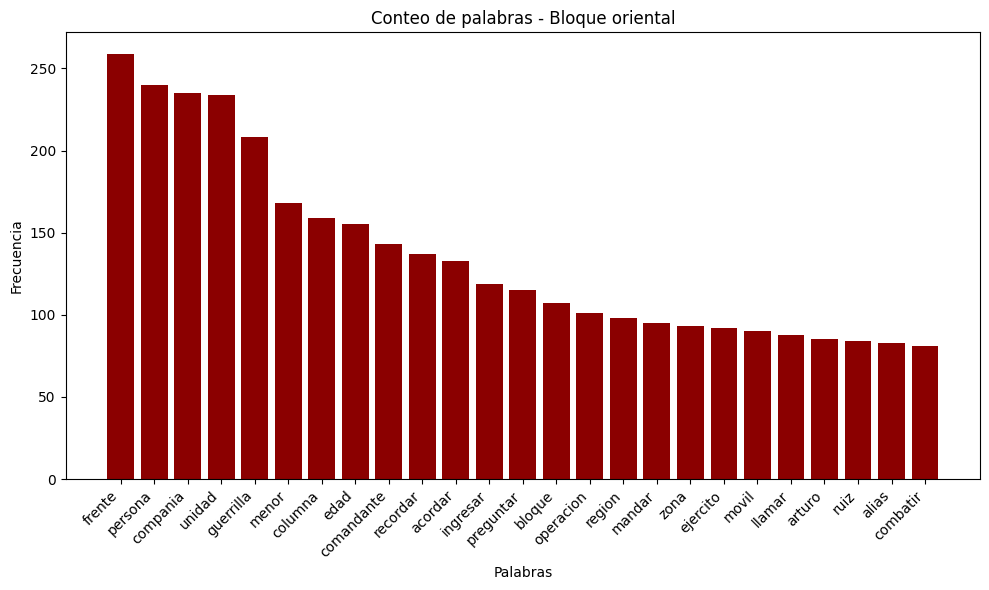

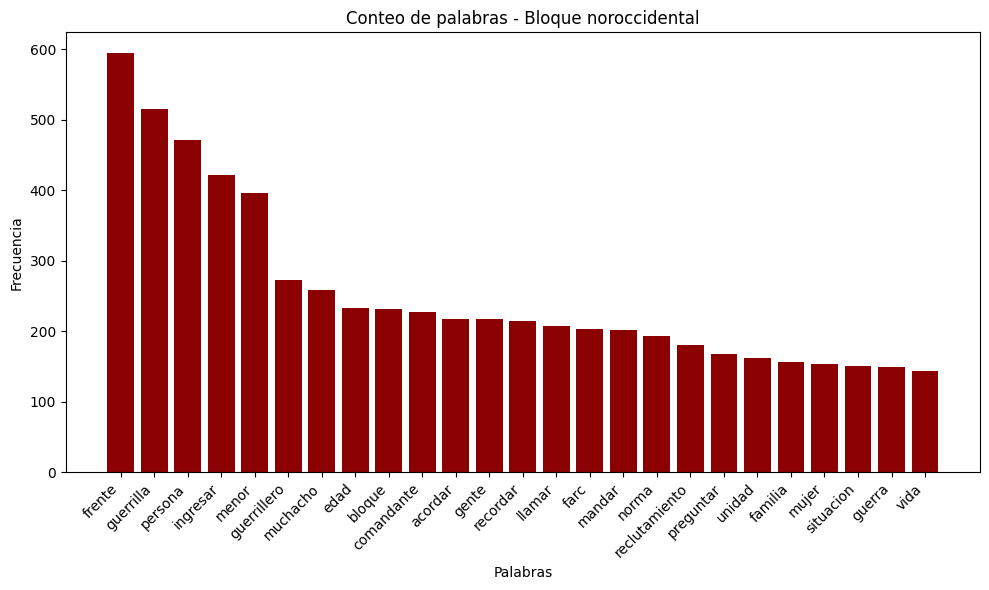

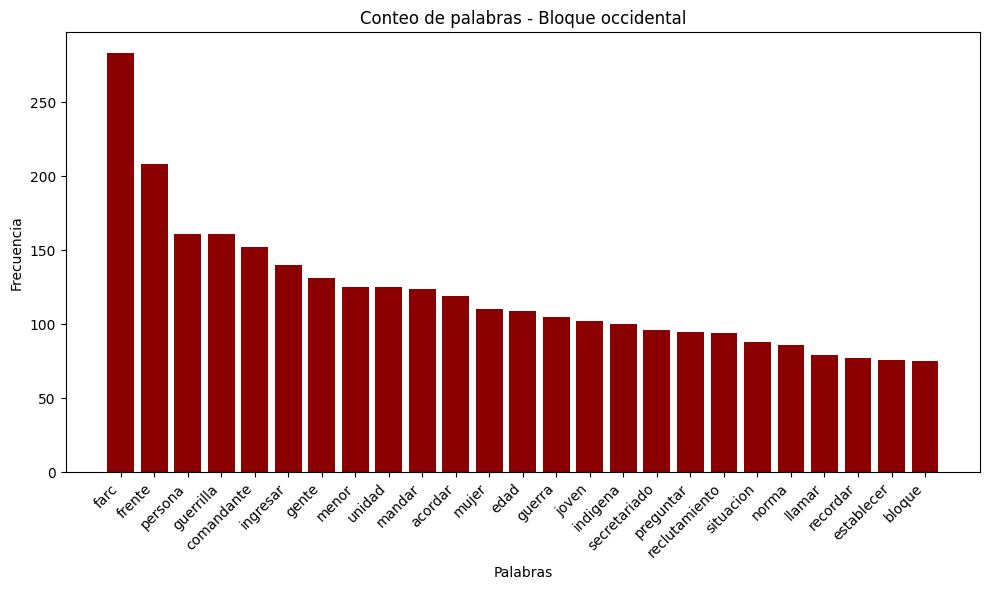

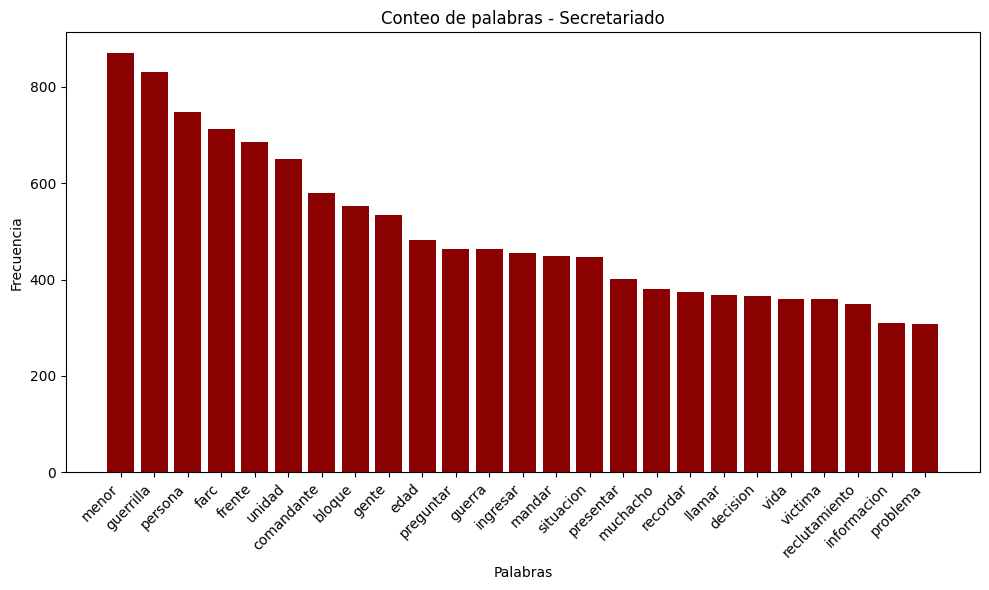

In [12]:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(25)
    palabras, frecuencias = zip(*palabras_repetidas)

    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color="darkred")
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(f"Conteo de palabras - {nombre.capitalize()}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



In [ ]:
##Frecuencia de palabras por subanálisis:
tablas_frecuencias = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(15)

    tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
    tablas_frecuencias[nombre] = tabla_frecuencias

    print(f"\n Frecuencias para: {nombre}")
    print(tabla_frecuencias)

tabla_final = pd.concat(tablas_frecuencias, names=['Grupo']).reset_index(level=0)
tabla_final.reset_index(drop=True, inplace=True)


 Frecuencias para: Bloque Oriental
       Palabra  Frecuencia
0       frente         259
1      persona         240
2     compania         235
3       unidad         234
4    guerrilla         208
5        menor         168
6      columna         159
7         edad         155
8   comandante         143
9     recordar         137
10     acordar         133
11    ingresar         119
12   preguntar         115
13      bloque         107
14   operacion         101

 Frecuencias para: Bloque Noroccidental
        Palabra  Frecuencia
0        frente         594
1     guerrilla         515
2       persona         471
3      ingresar         422
4         menor         396
5   guerrillero         272
6      muchacho         258
7          edad         233
8        bloque         231
9    comandante         227
10      acordar         217
11        gente         217
12     recordar         215
13       llamar         208
14         farc         203

 Frecuencias para: Bloque Occidental
     

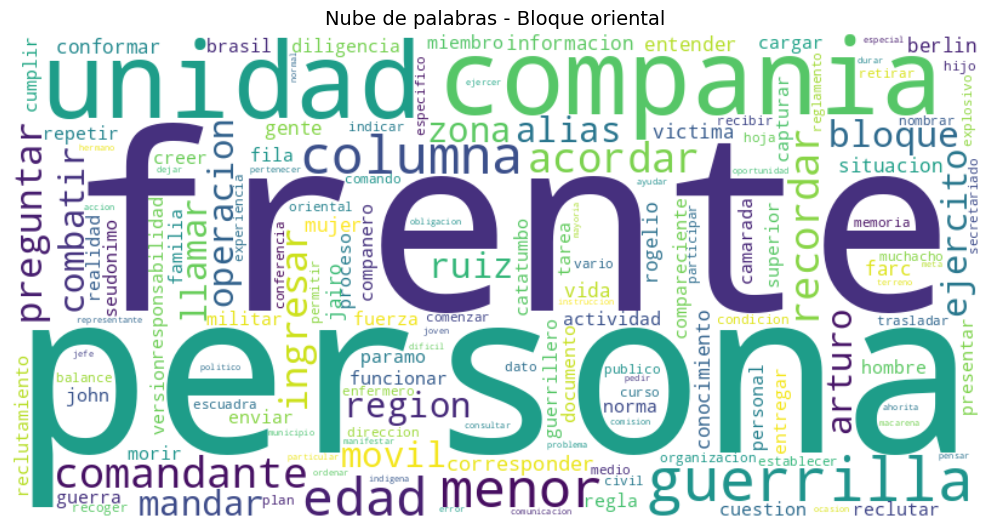

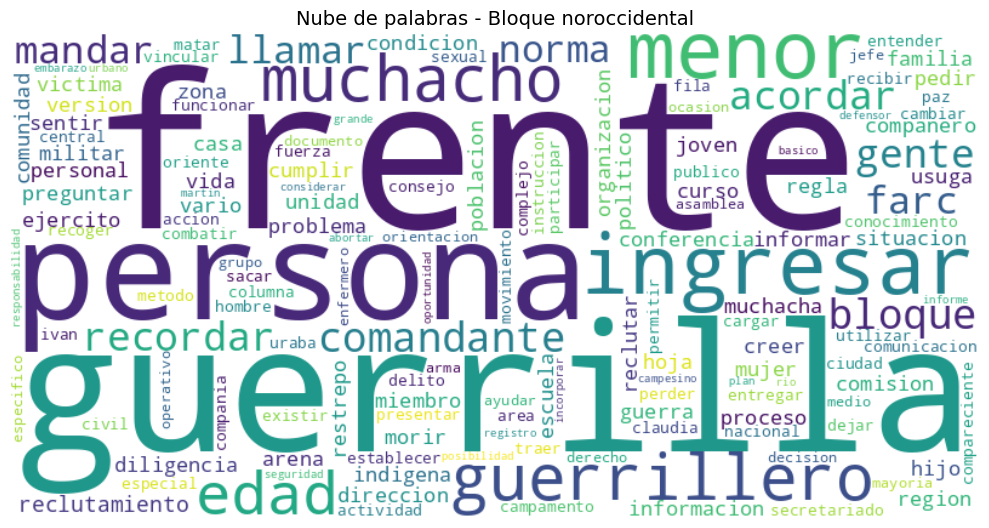

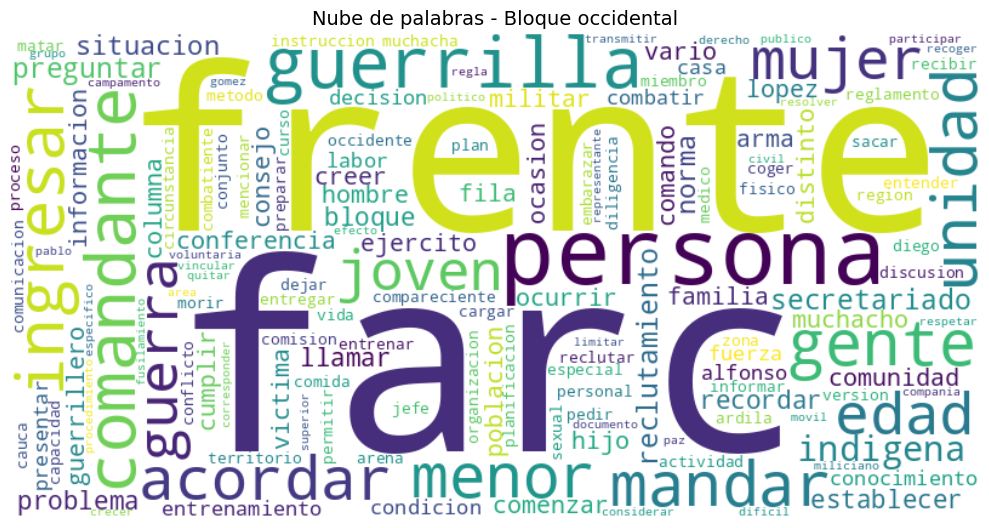

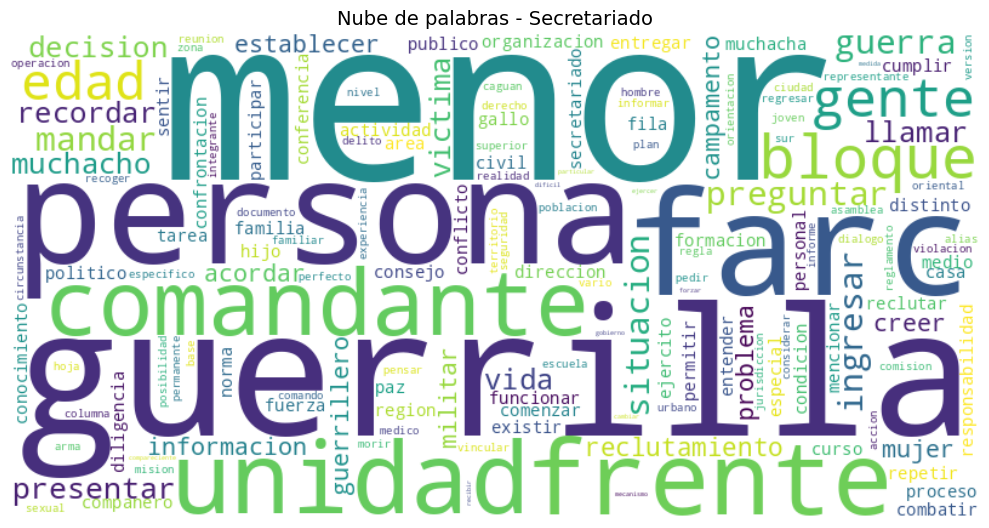

In [ ]:
#Nube de palabras por subanálisis:
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()
    frecuencia_palabras = FreqDist(tokens)

    nube = WordCloud(width=800, height=400,
        background_color='white',
        max_words=150
    ).generate_from_frequencies(frecuencia_palabras)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras - {nombre.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()



# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

lexico['Palabra'] = (
    lexico['Palabra'].astype(str).str.lower().str.strip().apply(unidecode).str.replace(r'[^a-zñáéíóúü\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True))

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')


resultados = []
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    # Normalizar
    tokens = [ re.sub(r'\s+', ' ',re.sub(r'[^a-zñáéíóúü\s]', '',
                      unidecode(t.lower().strip())))
        for t in word_tokenize(texto)]

    conteo = Counter({emo: 0 for emo in columnas_emociones})

    for token in tokens:
        if token in emociones:
            for emo, valor in emociones[token].items():
                conteo[emo] += valor

    conteo['Texto'] = nombre
    resultados.append(conteo)

df_emociones = pd.DataFrame(resultados)
df_emociones = df_emociones[['Texto'] + columnas_emociones]

# Traducir nombres de columnas
df_emociones = df_emociones.rename(columns={'Positive': 'Positivo','Negative': 'Negativo','Anger': 'Ira',
    'Anticipation': 'Anticipación','Disgust': 'Disgusto','Fear': 'Miedo','Joy': 'Alegría','Sadness': 'Tristeza',
    'Surprise': 'Sorpresa', 'Trust': 'Confianza'})
print(df_emociones.head())

                  Texto  Positivo  Negativo   Ira  Anticipación  Disgusto  \
0       Bloque Oriental      2470      1403   465           706       444   
1  Bloque Noroccidental      6066      4124  1529          1872      1507   
2     Bloque Occidental      2993      1952   855          1034       622   
3          Secretariado     13712      9354  3961          4808      3421   

   Miedo  Alegría  Tristeza  Sorpresa  Confianza  
0   1208      353       679       247       1660  
1   3210     1294      2023       836       4154  
2   1590      618      1000       422       2011  
3   7531     2788      4912      1707       9346  


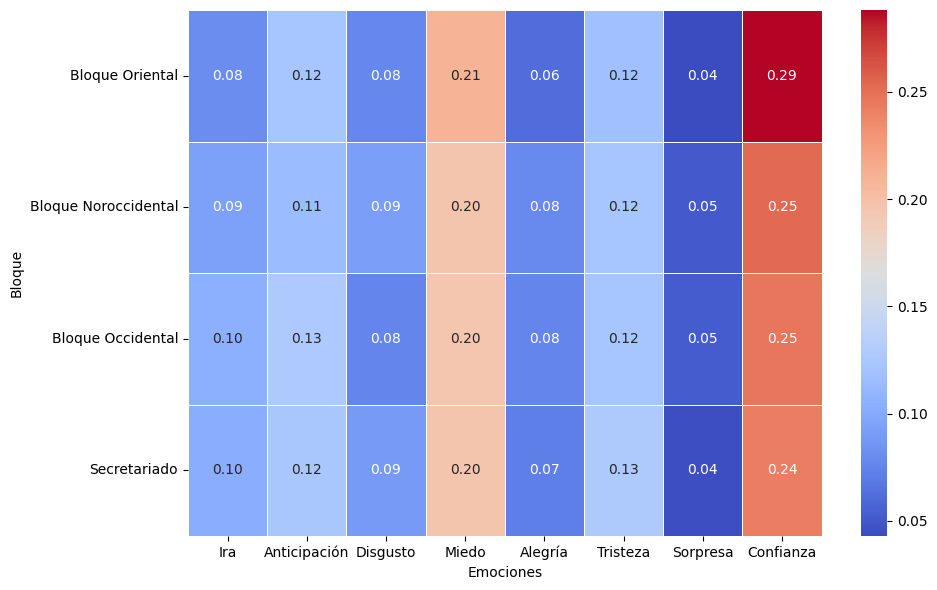

In [16]:
#Mapa de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)
plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Bloque')
plt.tight_layout()
plt.show()

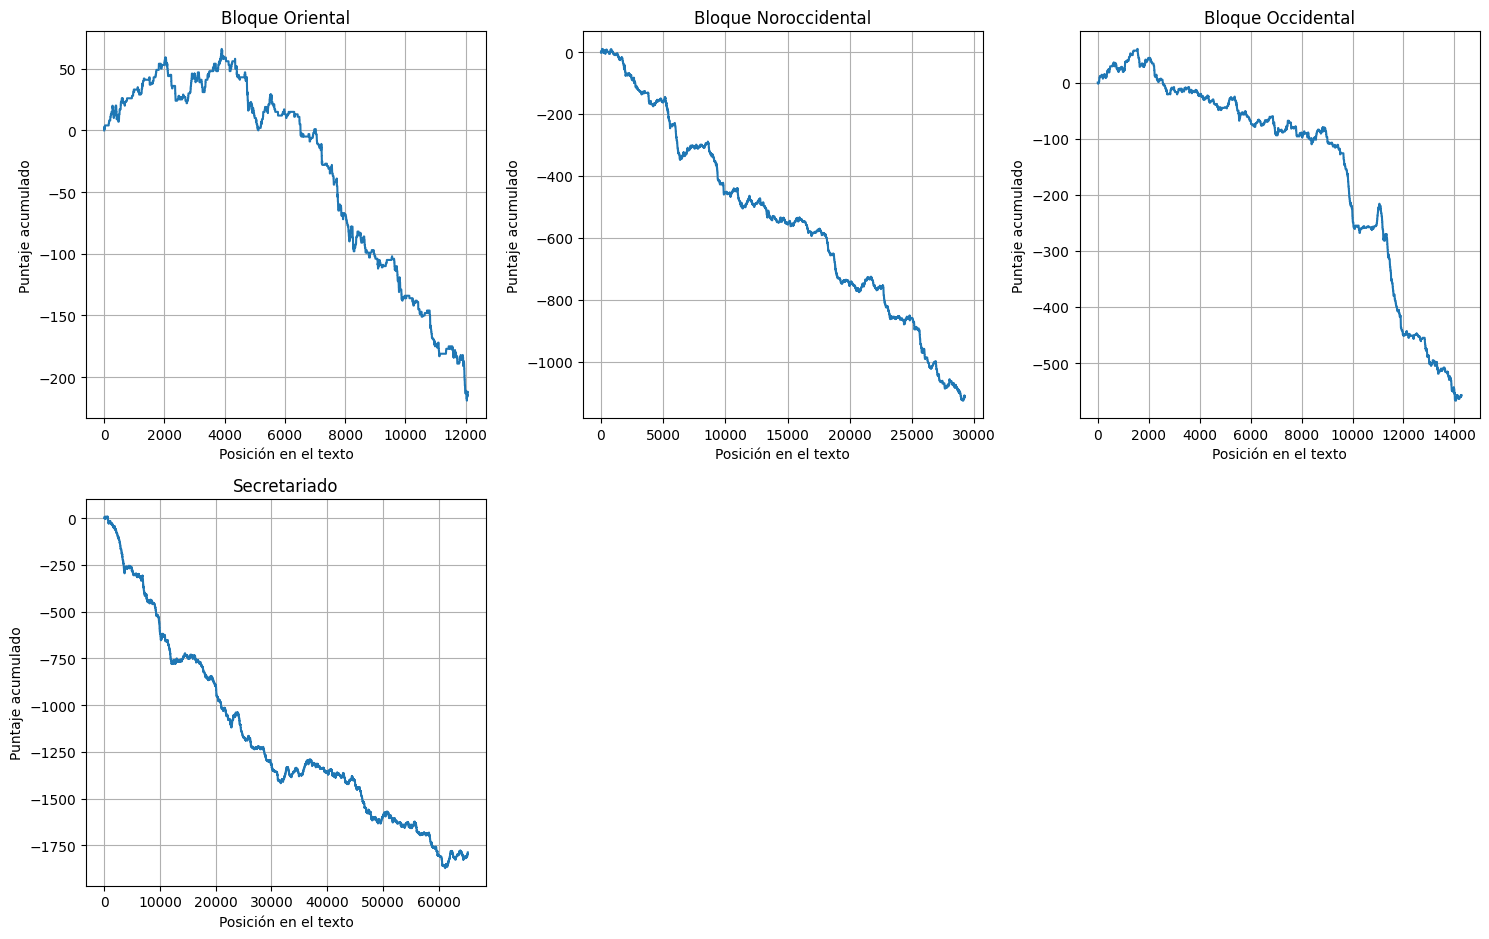

In [ ]:
##Grafico de sentimiento acumulado mediante diccionario AFINN
afinn = pd.read_csv("C:/Users/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")
afinn['palabra'] = afinn['palabra'].str.lower().str.strip()
afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))

tendencias_afinn = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = [
        unidecode(t.lower().strip())
        for t in word_tokenize(texto)]
    puntajes = [
        afinn_dict.get(token, 0)
        for token in tokens]

    df = pd.DataFrame({"palabra": tokens, "puntaje": puntajes})
    df["sentimiento_acumulado"] = df["puntaje"].cumsum()
    tendencias_afinn[nombre] = df

n = len(tendencias_afinn)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5* nrows))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, tendencias_afinn.items()):
    ax.plot(df.index, df["sentimiento_acumulado"])
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Posición en el texto")
    ax.set_ylabel("Puntaje acumulado")
    ax.grid(True)

for i in range(len(tendencias_afinn), len(axes)):
    axes[i].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# **RED BASICA**

In [18]:
def get_gigante(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

# ----------------------- Cálculo de métricas --------------------------------------------
redes_metrics = {}
centralidades_por_red = {}
top10_grado_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]

    G = nx.Graph()
    G.add_edges_from(skipgramas)

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = get_gigante(G)

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    # Métricas básicas
    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    # Top 10 por grado
    top10_grado = (
        pd.DataFrame(grados.items(), columns=["nodo", "grado"])
        .sort_values("grado", ascending=False)
        .head(10)
        .assign(porcentaje_grado=lambda x: x["grado"] / (2 * num_aristas))
    )
    top10_grado_por_red[nombre] = top10_grado

    # Centralidades
    nodos = list(G_gigante.nodes())
    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo": nodos,
        "grado": [grados[n] for n in nodos],
        "betweenness": [betweenness[n] for n in nodos],
        "closeness": [closeness[n] for n in nodos],
        "eigenvector": [eigenvector[n] for n in nodos]
    })
    centralidades_por_red[nombre] = df_centralidad

    redes_metrics[nombre] = {
        "num_nodos": num_nodos,
        "num_aristas": num_aristas,
        "densidad": nx.density(G_gigante),
        "grado_promedio": sum(grados.values()) / num_nodos,
        "transitividad_global": nx.transitivity(G_gigante),
        "assortatividad_grado": nx.degree_assortativity_coefficient(G_gigante),
        "diametro": nx.diameter(G_gigante),
        "longitud_media_camino": nx.average_shortest_path_length(G_gigante),
        "betweenness_media": df_centralidad["betweenness"].mean(),
        "betweenness_max": df_centralidad["betweenness"].max(),
        "closeness_media": df_centralidad["closeness"].mean(),
        "eigenvector_media": df_centralidad["eigenvector"].mean(),
        "grado_max": top10_grado["grado"].max(),
        "grado_medio_top10": top10_grado["grado"].mean(),
        "concentracion_top10": top10_grado["grado"].sum() / (2 * num_aristas),
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print("\nMétricas")
print(df_metrics)

Grafo 'Bloque Oriental': 933 nodos, 4695 aristas (componente gigante).
Grafo 'Bloque Noroccidental': 1617 nodos, 11285 aristas (componente gigante).
Grafo 'Bloque Occidental': 1138 nodos, 5800 aristas (componente gigante).
Grafo 'Secretariado': 2756 nodos, 39228 aristas (componente gigante).

Métricas
                      num_nodos  num_aristas  densidad  grado_promedio  \
Bloque Oriental             933         4695  0.010799       10.064309   
Bloque Noroccidental       1617        11285  0.008637       13.957947   
Bloque Occidental          1138         5800  0.008965       10.193322   
Secretariado               2756        39228  0.010333       28.467344   

                      transitividad_global  assortatividad_grado  diametro  \
Bloque Oriental                   0.192815             -0.107837         8   
Bloque Noroccidental              0.176414             -0.139304         8   
Bloque Occidental                 0.151418             -0.073436         9   
Secretariado  

In [19]:
top10_grado_por_red

{'Bloque Oriental':            nodo  grado  porcentaje_grado
 176      frente    193          0.020554
 223     persona    183          0.019489
 216   guerrilla    174          0.018530
 234      unidad    167          0.017785
 178       menor    116          0.012354
 266  comandante    111          0.011821
 86     recordar    109          0.011608
 222        edad    109          0.011608
 238     columna    107          0.011395
 92      acordar    106          0.011289,
 'Bloque Noroccidental':             nodo  grado  porcentaje_grado
 175    guerrilla    357          0.015817
 243       frente    354          0.015685
 56       persona    337          0.014931
 14      ingresar    262          0.011608
 217        menor    258          0.011431
 177  guerrillero    212          0.009393
 263     muchacho    201          0.008906
 43          farc    191          0.008463
 6       recordar    184          0.008152
 82       acordar    183          0.008108,
 'Bloque Occidental'

In [ ]:
### Top nodos por centralidad y grado máximo
def max_info(df, col):
    idx = df[col].idxmax()
    return df.loc[idx, col], df.loc[idx, "nodo"]

redes_metrics = {}
centralidades_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    G = nx.Graph()
    G.add_edges_from(datos["skipgramas_filtrados"])

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo":        list(G_gigante.nodes()),
        "grado":       [grados[n]      for n in G_gigante.nodes()],
        "betweenness": [betweenness[n] for n in G_gigante.nodes()],
        "closeness":   [closeness[n]   for n in G_gigante.nodes()],
        "eigenvector": [eigenvector[n] for n in G_gigante.nodes()]
    })
    centralidades_por_red[nombre] = df_centralidad

    grado_max,  nodo_grado_max = max_info(df_centralidad, "grado")
    betw_max,   nodo_betw_max  = max_info(df_centralidad, "betweenness")
    close_max,  nodo_close_max = max_info(df_centralidad, "closeness")
    eig_max,    nodo_eig_max   = max_info(df_centralidad, "eigenvector")

    redes_metrics[nombre] = {
        "num_nodos":             num_nodos,
        "grado_max":             grado_max,       "nodo_grado_max":       nodo_grado_max,
        "betweenness_max":       betw_max,         "nodo_betweenness_max": nodo_betw_max,
        "closeness_max":         close_max,        "nodo_closeness_max":   nodo_close_max,
        "eigenvector_max":       eig_max,          "nodo_eigenvector_max": nodo_eig_max,
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print(df_metrics)

Grafo 'Bloque Oriental': 933 nodos, 4695 aristas (componente gigante).
Grafo 'Bloque Noroccidental': 1617 nodos, 11285 aristas (componente gigante).
Grafo 'Bloque Occidental': 1138 nodos, 5800 aristas (componente gigante).
Grafo 'Secretariado': 2756 nodos, 39228 aristas (componente gigante).
                      num_nodos  grado_max nodo_grado_max  betweenness_max  \
Bloque Oriental             933        193         frente         0.113477   
Bloque Noroccidental       1617        357      guerrilla         0.100835   
Bloque Occidental          1138        238           farc         0.123875   
Secretariado               2756        656      guerrilla         0.059019   

                     nodo_betweenness_max  closeness_max nodo_closeness_max  \
Bloque Oriental                    frente       0.508456            persona   
Bloque Noroccidental               frente       0.531404             frente   
Bloque Occidental                    farc       0.510782               farc   


# **ANALISIS DE REDES SOBRE CRÍMENES**

In [20]:
## Crear subredes a partir de términos específicos asociados a los crímenes en contra de los menores de edad
##Nota: estos crímenes se obtuvieron de una búsqueda en la especificación del caso en la página web de la JEP, además de
##diferentes observaciones en los resultados obtenidos en el código:

terminos_crimenes = ["abortar", "aborto", "abusado", "abusar", "abusivo", "abuso", "violacion", "violador", "violar", "homicidio", "matar", "reclutar",
    "reclutamiento", "reproductivo", "desaparicion", "desaparecer", "torturar", "fusilar", "secuestro",
    "secuestrar", "violencia", "suxual", "abortar", "aborto", "abusado", "abusar", "abusivo", "abuso",
    "asesinato", "asesino", "atentar", "autoincriminacion", "desaparecer", "desaparecidos", "desaparicion",
    "desminado", "desplazamiento", "desplazar", "discriminacion", "discriminar", "discriminatorio",
    "exterminar", "exterminio", "fusil", "fusilamiento", "fusilar", "fusile", "herida", "homicidio",
     "lesion", "lesionar", "maltratar", "maltrato", "masacrar", "masacre", "masacres", "minar", "muerte", "reclutador",
    "reclutamiento", "reclutar", "robar", "robo", "secuestrar", "secuestro", "torturar", "violacion", "violador", "violar",
    "violatorio", "violencia", "violento"]

terminos_crimenes = [unidecode(t.lower()) for t in terminos_crimenes]
subredes_violencia = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]
    G = nx.Graph() ##Grafo completo
    G.add_edges_from(skipgramas)

    # --- construir subred ---
    nodos_subred = set()

    for t in terminos_crimenes:
        if t in G:
            nodos_subred.add(t)
            nodos_subred.update(G.neighbors(t))
    # Crear subgrafo
    subG = G.subgraph(nodos_subred).copy()

    if subG.number_of_nodes() > 0:
        subredes_violencia[nombre] = subG
resumen = []

for nombre, subG in subredes_violencia.items():
    resumen.append({"bloque": nombre,"n_nodos": subG.number_of_nodes(),"n_aristas": subG.number_of_edges(),"densidad": nx.density(subG)})

df_resumen = pd.DataFrame(resumen)
print(df_resumen)

                 bloque  n_nodos  n_aristas  densidad
0       Bloque Oriental      104        857  0.160007
1  Bloque Noroccidental      327       4546  0.085289
2     Bloque Occidental      205       1513  0.072358
3          Secretariado      756      19344  0.067781


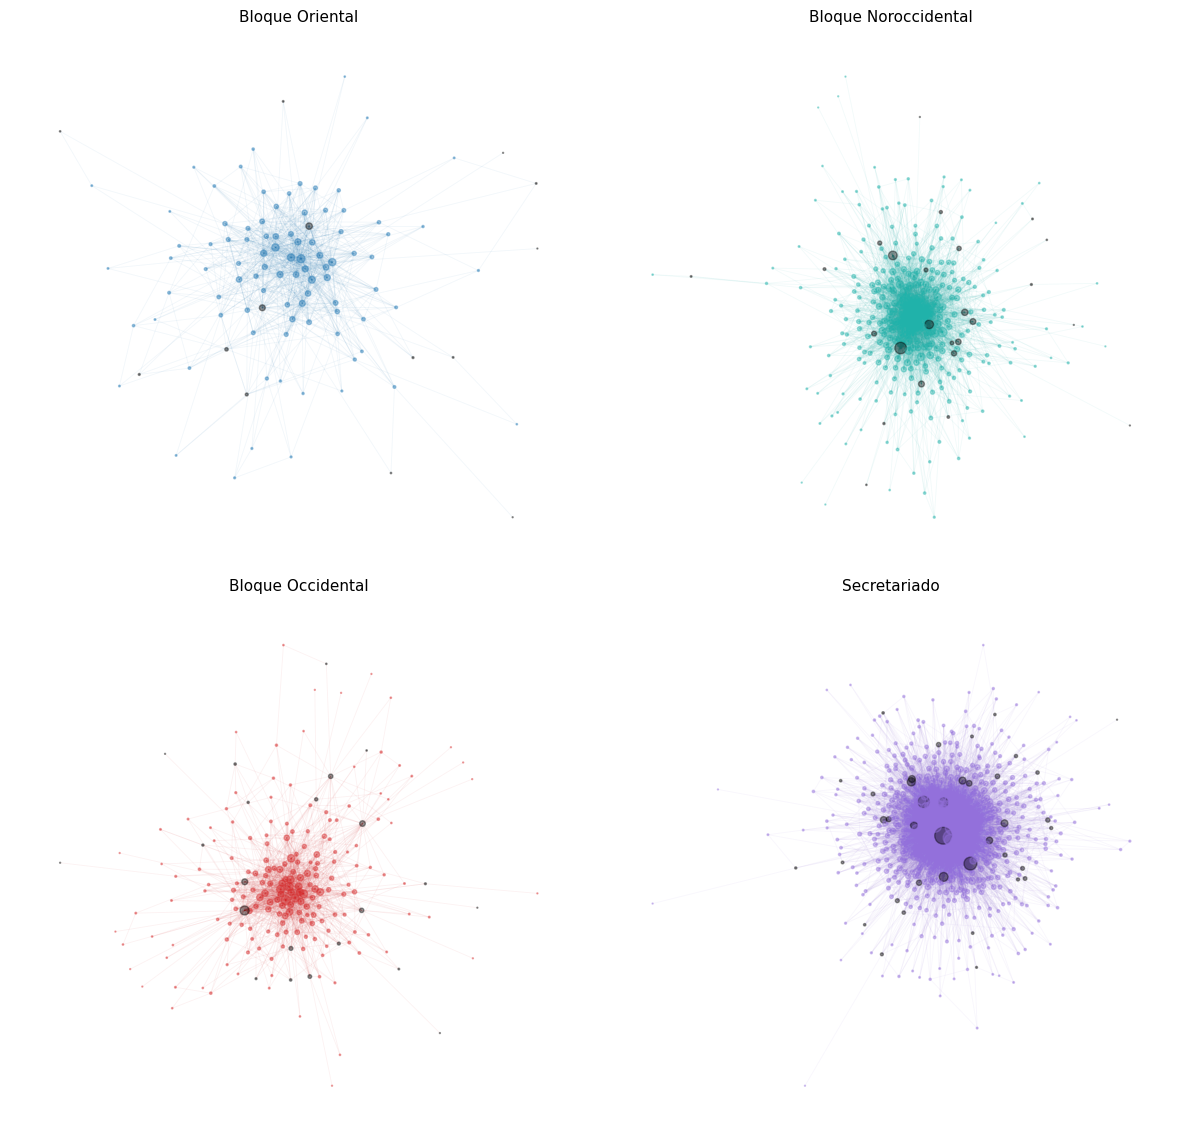

In [21]:
nombres_bloques = {"oriental": "Bloque Oriental","noroccidental": "Bloque Noroccidental","secretariado": "Secretariado",
    "occidental": "Bloque Occidental"}
colores_personas = {"oriental": "#1f77b4","noroccidental": "#20B2AA","secretariado": "#9370DB","occidental": "#d62728"}
color_crimenes = "black"

n = len(subredes_violencia)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6 * nrows))
axes = axes.flatten()

top_nodos_por_bloque = []
for ax, (nombre, subG) in zip(axes, subredes_violencia.items()):

    color_bloque = "#999999"
    for key in colores_personas:
        if key in nombre.lower():
            color_bloque = colores_personas[key]
            break

    n_nodos = subG.number_of_nodes()
    k = 1.5 / (n_nodos ** 0.4) ###Si se quiere modificar la separación de cada grafo así mejorar
    ##la visibilidad de la red (ej. aumentarlo para las redes más grandes B Noroccidental y secretariado)

    pos = nx.spring_layout(subG,k=k,iterations=200,seed=42)
    grados = dict(subG.degree())
    tamanios = [grados[n] * 0.5 for n in subG.nodes()]
    top_k = 5
    top_nodos = sorted(grados.items(),key=lambda x: x[1],reverse=True)[:top_k]
    colores_nodos = [
        color_crimenes if n in terminos_crimenes else color_bloque
        for n in subG.nodes()]

    nx.draw_networkx_nodes(subG, pos,node_size=tamanios,node_color=colores_nodos,alpha=0.4,ax=ax)
    nx.draw_networkx_edges(subG, pos,edge_color=color_bloque,alpha=0.06,width=0.6,ax=ax)

    titulo = nombre
    for key, full_name in nombres_bloques.items():
        if key in nombre.lower():
            titulo = full_name
            break

    ax.set_title(titulo, fontsize=11)
    ax.axis("off")

for i in range(len(subredes_violencia), len(axes)):
    axes[i].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [22]:
##Nodos con mayor  grrado cada una de las sub redes:
top_nodos_por_bloque = []
top_k = 5
for nombre, subG in subredes_violencia.items():
    titulo = nombre
    for key, full_name in nombres_bloques.items():
        if key in nombre.lower():
            titulo = full_name
            break
    grados = dict(subG.degree())
    top_nodos = sorted(grados.items(),key=lambda x: x[1],reverse=True)[:top_k]
    for nodo, grado in top_nodos:top_nodos_por_bloque.append({"bloque": titulo,"nodo": nodo,"grado": grado})
df_top_grado = pd.DataFrame(top_nodos_por_bloque)
df_top_grado


,bloque,nodo,grado
0,Bloque Oriental,persona,67
1,Bloque Oriental,frente,56
2,Bloque Oriental,guerrilla,56
3,Bloque Oriental,unidad,53
4,Bloque Oriental,menor,49
5,Bloque Noroccidental,persona,186
6,Bloque Noroccidental,guerrilla,178
7,Bloque Noroccidental,frente,173
8,Bloque Noroccidental,menor,157
9,Bloque Noroccidental,ingresar,142


In [29]:
#Grado de los nodos con los cuales se elaboraron las sub redes:
filas = []
for nombre, subG in subredes_violencia.items():
    grados = dict(subG.degree())

    for termino in terminos_crimenes:
        if termino in subG:
            filas.append({"bloque": nombre,"nodo": termino,"grado": grados[termino]})
df_crim = pd.DataFrame(filas)

#Eliminar duplicados
df_crim = pd.DataFrame(filas)
df_crim = df_crim.drop_duplicates(subset=["bloque", "nodo"]).reset_index(drop=True)
df_crim

,bloque,nodo,grado
0,Bloque Oriental,abortar,4
1,Bloque Oriental,aborto,3
2,Bloque Oriental,abusar,1
3,Bloque Oriental,violacion,1
4,Bloque Oriental,violar,4
...,...,...,...
95,Secretariado,muerte,43
96,Secretariado,robar,8
97,Secretariado,robo,6
98,Secretariado,violatorio,25


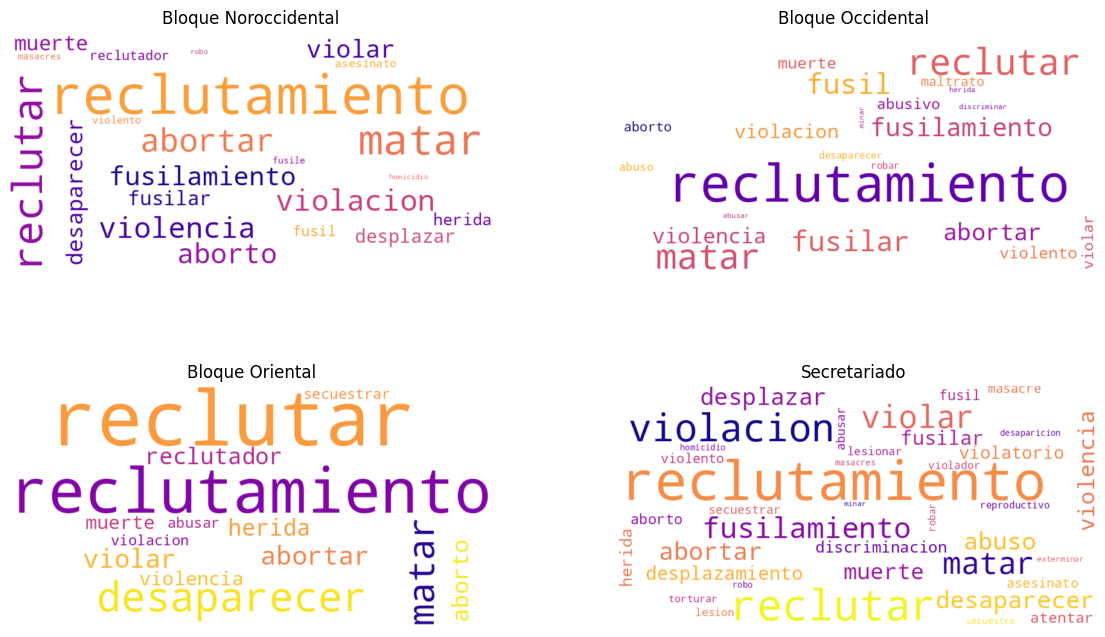

In [ ]:
#Nubes de palabras por subanálisis de los crímenes
nodos_por_bloque = {bloque: dict(zip(df_b["nodo"], df_b["grado"]))
    for bloque, df_b in df_crim.groupby("bloque")}

n = len(nodos_por_bloque)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows=2,ncols=2,figsize=(14, 8))
fig.subplots_adjust(wspace=0.25,hspace=0.35)

axes = axes.flatten()
for ax, (bloque, pesos) in zip(axes, nodos_por_bloque.items()):

    if len(pesos) == 0:
        ax.axis("off")
        continue

    wc = WordCloud(width=800,height=400,background_color="white",colormap="plasma",
        prefer_horizontal=0.9,min_font_size=12).generate_from_frequencies(pesos)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(bloque, fontsize=12)
    ax.axis("off")

